In [43]:
# TASK 01 - Implement a linear regression model to predict the prices of houses based on their square footage and the number of bedrooms and bathrooms.
# TASK 02 - Create a K-means clustering algorithm to group customers of a retail store based on their purchase history.
# TASK 03 - Implement a support vector machine (SVM) to classify images of cats and dogs from the Kaggle dataset.
# TASK 04 - Develop a hand gesture recognition model that can accurately identify and classify different hand gestures from image or video data, enabling intuitive human-computer interaction and gesture-based control systems.
# TASK 05 - Develop a model that can accurately recognize food items from images and estimate their calorie content, enabling users to track their dietary intake and make informed food choices.

# <h><center><b>**Prodigy InfoTech Internship Program**</b></center></h>
### <h><center><b>**TASK 03 - Cat Dog Classification**</b></center></h>

**GitHub Repository-** **https://github.com/anweshabose/PRODIGY_ML_03**

<h1><b>Cat Dog Classification using SVM in CNN</b></h1>

![](https://cdn.analyticsvidhya.com/wp-content/uploads/2021/06/how-to-do-Cat-and-Dog-Classification-using-CNN_-How-to-do-Cat-and-Dog-Classification-using-CNN_-01-scaled.jpg)

# **Data Set Problems** 🤔

👉 Implement a **support vector machine (SVM)** in **CNN** to classify images of cats and dogs from the Kaggle dataset.

---

👨‍💻 **The machine learning models used in this project are:**
1. Support Vector Machine (SVM)
2. Convolution Neural Network(CNN)

# **Project Outline**

**Steps that we follow:**

- Installing and importing all the required libraries.
- configuration
- Version of Tensorflow
- Data Preprocessing & making the training and testing set
- Building the CNN structure
- Model Summary
- Training the CNN Model
- Graphical view of Accuracy and Loss of the CNN Model
- Saving the Model
- Loading the Model
- Model Summary
- Making prediction on new data (single prediction)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Installing and importing all the required libraries

In [11]:
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import numpy as np
from tensorflow.keras.preprocessing import image

# Configuration

In [12]:
#config = ConfigProto()
#config.gpu_options.per_process_gpu_memory_fraction = 0.5
#config.gpu_options.allow_growth = True
#session = InteractiveSession(config=config)

# Version of Tensorflow

In [13]:
tf.__version__

'2.18.0'

# Data Preprocessing & making the training and testing set

In [14]:
##### Make sure that you have "cat" and "dog" folders inside both train and test1 folder. If not, then make it.

In [15]:
# Preprocessing the Training set
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

training_set = train_datagen.flow_from_directory('/content/drive/MyDrive/Cat_Dog_Classification_Dataset/train',
                                                 target_size = (64, 64),
                                                 batch_size = 32,
                                                 class_mode = 'binary')

Found 23010 images belonging to 2 classes.


In [16]:
# Preprocessing the Test set
test_datagen = ImageDataGenerator(rescale = 1./255)
test_set = test_datagen.flow_from_directory('/content/drive/MyDrive/Cat_Dog_Classification_Dataset/test1',
                                            target_size = (64, 64),
                                            batch_size = 32,
                                            class_mode = 'binary')

Found 2000 images belonging to 2 classes.


# Building the CNN structure

![](https://projectgurukul.org/wp-content/uploads/2022/08/cnn-convolutional-neural-networks.webp)

In [17]:
# Initialising the CNN
cnn = tf.keras.models.Sequential()

# Making the Convolution layer
cnn.add(tf.keras.layers.Conv2D(filters=32,padding="same",kernel_size=3, activation='relu', strides=2, input_shape=[64, 64, 3]))

# Making the Pooling layer
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

# Adding a second convolutional and pooling layer
cnn.add(tf.keras.layers.Conv2D(filters=32,padding='same',kernel_size=3, activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

# Making the Flattening layer
cnn.add(tf.keras.layers.Flatten())

# Making the Hidden layer
cnn.add(tf.keras.layers.Dense(units=128, activation='relu'))

# Making the Output layer (for normal CNN)
# cnn.add(tf.keras.layers.Dense(units=1, activation='sigmoid')) # For Binary Classification of normal CNN
# cnn.add(tf.keras.layers.Dense(units=1, activation='softmax')) # For Multiple Classification of normal CNN

# Making the Output layer (using SVM in CNN)
cnn.add(Dense(1, kernel_regularizer=tf.keras.regularizers.l2(0.01),activation='linear')) # For Binary Classification of using SVM in CNN
# cnn.add(Dense(4, kernel_regularizer=tf.keras.regularizers.l2(0.01),activation='softmax')) # For Multiple Classification of using SVM in CNN

# Model Summary

In [18]:
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 272,545 (1.04 MB)

 Trainable params: 272,545 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

# Training the CNN Model

In [21]:
# For normal CNN
# cnn.compile(loss='bimary_crossentropy', optimizer='adam', metrics=['accuracy']) # For Binary Classification for normal CNN
# cnn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy']) # For Multiple Classification for normal CNN

# For SVM in CNN
cnn.compile(optimizer = 'adam', loss = 'hinge', metrics = ['accuracy']) # For Binary Classification of using SVM in CNN
# cnn.compile(optimizer = 'adam', loss = 'squared_hinge', metrics = ['accuracy']) # For Multiple Classification of using SVM in CNN

# Training the CNN on the Training set and evaluating it on the Test set
r=cnn.fit(x = training_set, validation_data = test_set, epochs = 5)

Epoch 1/5
720/720 ━━━━━━━━━━━━━━━━━━━━ 367s 507ms/step - accuracy: 0.6856 - loss: 0.6740 - val_accuracy: 0.7555 - val_loss: 0.6261
Epoch 2/5
720/720 ━━━━━━━━━━━━━━━━━━━━ 192s 267ms/step - accuracy: 0.7259 - loss: 0.5890 - val_accuracy: 0.7785 - val_loss: 0.5323
Epoch 3/5
720/720 ━━━━━━━━━━━━━━━━━━━━ 198s 275ms/step - accuracy: 0.7474 - loss: 0.5439 - val_accuracy: 0.7915 - val_loss: 0.5005
Epoch 4/5
720/720 ━━━━━━━━━━━━━━━━━━━━ 202s 281ms/step - accuracy: 0.7640 - loss: 0.5121 - val_accuracy: 0.7940 - val_loss: 0.5157
Epoch 5/5
720/720 ━━━━━━━━━━━━━━━━━━━━ 192s 267ms/step - accuracy: 0.7730 - loss: 0.5041 - val_accuracy: 0.7900 - val_loss: 0.4810


# Graphical view of Accuracy and Loss of the CNN Model

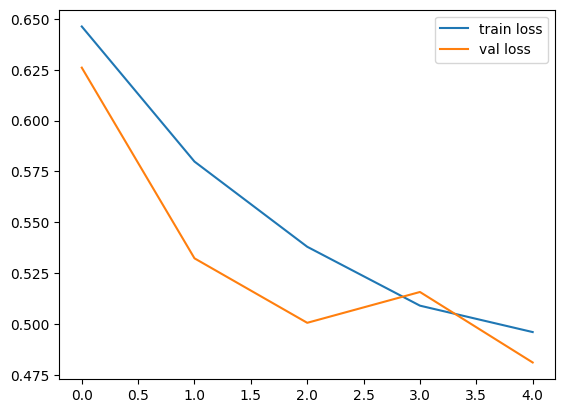

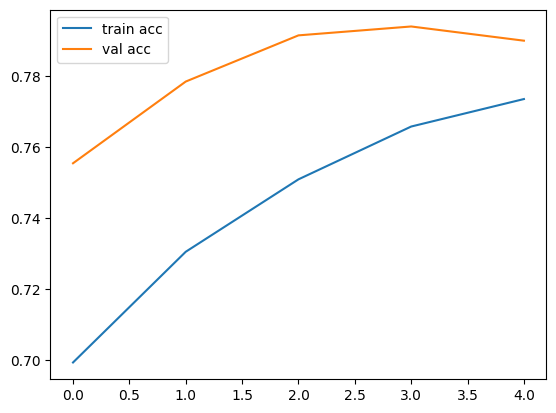

<Figure size 640x480 with 0 Axes>

In [22]:
# plot the loss
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

# plot the accuracy
plt.plot(r.history['accuracy'], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')

# Saving the Model

In [23]:
# save it as a h5 file
cnn.save('model_rcat_dog.h5')

# Loading the Model

In [24]:
# load model
model = load_model('model_rcat_dog.h5')

# Model Summary

In [25]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 272,547 (1.04 MB)

 Trainable params: 272,545 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

# Making prediction on new data (single prediction)

In [31]:
test_image = image.load_img('/content/drive/MyDrive/Cat_Dog_Classification_Dataset/test1/dog/dog.11519.jpg', target_size = (64,64))
test_image = image.img_to_array(test_image)
test_image=test_image/255
test_image = np.expand_dims(test_image, axis = 0)
result = cnn.predict(test_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [32]:
result

array([[0.01631979]], dtype=float32)

In [33]:
if result[0]<0:
    print("The image classified is cat")
else:
    print("The image classified is dog")

The image classified is dog


In [40]:
test_image = image.load_img('/content/drive/MyDrive/Cat_Dog_Classification_Dataset/test1/cat/cat.11517.jpg', target_size = (64,64))
test_image = image.img_to_array(test_image)
test_image=test_image/255
test_image = np.expand_dims(test_image, axis = 0)
result = cnn.predict(test_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


In [41]:
result

array([[-0.66270584]], dtype=float32)

In [42]:
if result[0]<0:
    print("The image classified is cat")
else:
    print("The image classified is dog")

The image classified is cat
